In [1]:
# homework8
# 2 Pandas DataFrame
# 2.1 - 2.3
import pandas as pd
df = pd.read_csv("../../course_assignments/homework8/state_data.csv")

In [2]:
# 2.4
print(df.shape)
# There are 52 rows and 4 columns

(52, 4)


In [3]:
# 2.5
print(df.head(5))
print(df.tail(5))
# The columns are categories of information about the states
# The first state is Alaska
# The last stae is Wyoming
# There are 52 total entries
# Puerto Rico and the District of Columbia are included

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [4]:
# 2.6
median_lat = df["latitude"].median()
print(median_lat)
median_lon = df["longitude"].median()
print(median_lon)
# The median latitude is 39.4355155 and the median longitude is -89.093198

39.4355155
-89.093198


In [5]:
# 2.7
df["latitude_distance"] = df["latitude"] - median_lat

In [6]:
# 2.8
df["longitude_distance"] = df["longitude"] - median_lon

In [7]:
# 2.9
print(df.shape)
# It has 52 rows and 6 columns

(52, 6)


In [8]:
# 2.10
idx_closest_lat = df["latitude_distance"].idxmin()
print(f"Closest to median latitude: {df.loc[idx_closest_lat, 'name']}, {df.loc[idx_closest_lat, 'latitude_distance']:.2f}")

idx_farthest_lat = df["latitude_distance"].idxmax()
print(f"Farthest from median latitude: {df.loc[idx_farthest_lat, 'name']}, {df.loc[idx_farthest_lat, 'latitude_distance']:.2f}")

idx_closest_lon = df["longitude_distance"].idxmin()
print(f"Closest to median longitude: {df.loc[idx_closest_lon, 'name']}, {df.loc[idx_closest_lon, 'longitude_distance']:.2f}")

idx_farthest_lon = df["longitude_distance"].idxmax()
print(f"Farthest from median longitude: {df.loc[idx_farthest_lon, 'name']}, {df.loc[idx_farthest_lon, 'longitude_distance']:.2f}")

Closest to median latitude: Puerto Rico, -21.21
Farthest from median latitude: Alaska, 24.15
Closest to median longitude: Hawaii, -66.57
Farthest from median longitude: Puerto Rico, 22.50


In [9]:
# 2.11
stacked = df.stack()
print(stacked)
# I found this function in the 10 minutes to pandas guide on the website under reshaping.
# This function stacks the information from the different columns into rows. It is helpful to use when you want compress a dataframe in a direction.

0   state                         AK
    latitude               63.588753
    longitude            -154.493062
    name                      Alaska
    latitude_distance      24.153237
                             ...    
51  latitude               43.075968
    longitude            -107.290284
    name                     Wyoming
    latitude_distance       3.640453
    longitude_distance    -18.197086
Length: 312, dtype: object


In [10]:
# 3 Seaborn
# 3.1-3.4
import matplotlib.pyplot as plt
import seaborn as sns

df2 = sns.load_dataset("penguins")

In [11]:
# 3.5
df2 = df2.dropna()

In [12]:
# 3.6
print(df2.shape)
print(df2.head(5))
print(df2.tail(5))
# It has 333 rows and 7 columns
# The columns are: species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex
# The column names are mostly self explanatory, with bill depth measuring the vertical height of the bill and length measuring the longest horizontal length.

(333, 7)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
338  Gentoo  Biscoe            47.2           13.7              214.0   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4           15.7              222.0   
342  Gentoo  Biscoe            45.2           14.8              212.0   
343  Gentoo  Biscoe            

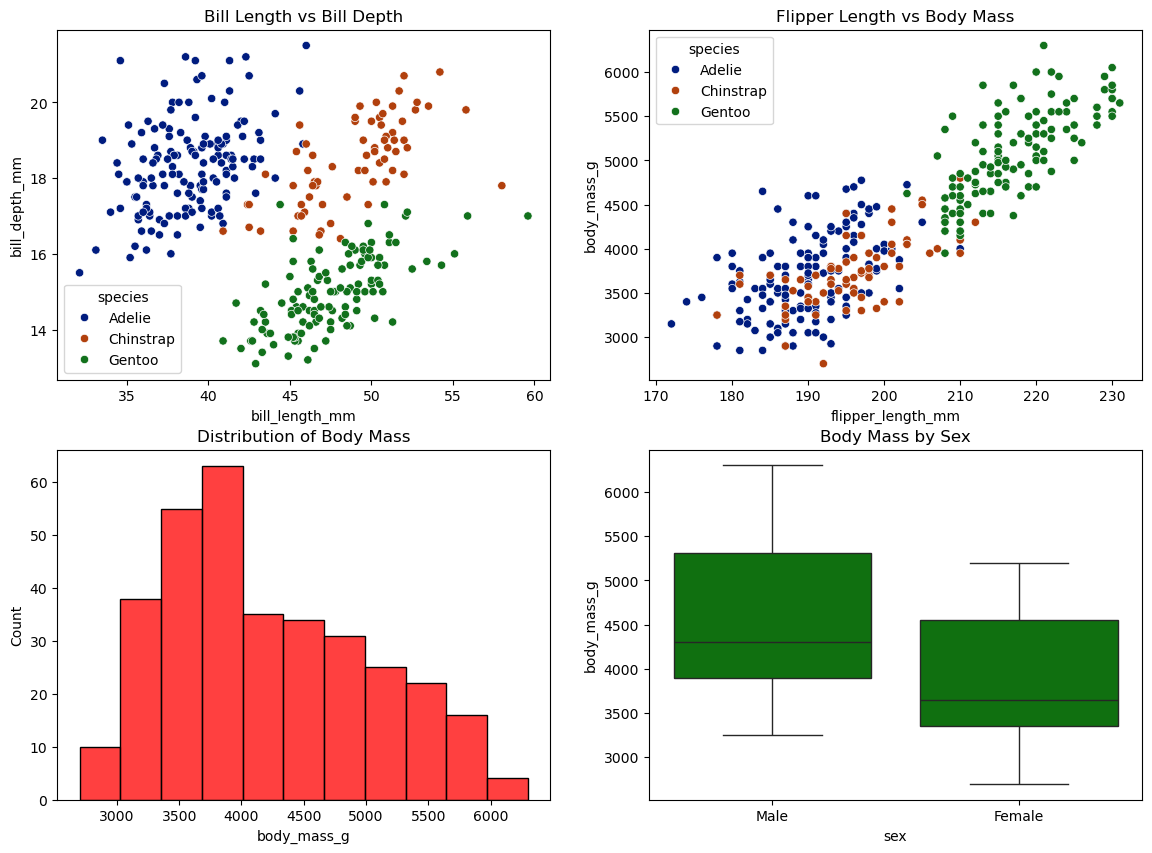

In [13]:
# 3.7 - 3.8
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df2, x="bill_length_mm", color="purple", hue="species", palette="dark", y="bill_depth_mm", ax=axes[0, 0])
axes[0, 0].set_title("Bill Length vs Bill Depth")

sns.scatterplot(data=df2, x="flipper_length_mm", y="body_mass_g", hue="species", palette="dark", ax=axes[0, 1])
axes[0, 1].set_title("Flipper Length vs Body Mass")

sns.histplot(data=df2, x="body_mass_g", color="red", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Body Mass")

sns.boxplot(data=df2, x="sex", y="body_mass_g", color="green", ax=axes[1, 1])
axes[1, 1].set_title("Body Mass by Sex")

plt.show()

In [14]:
# 3.9
# The top left subplot represents bill depth vs bill length. Because both measurements are about the bills, it made sense to relate them. Originally, this seemed random, but when color coding it by different species it becomes clear that there is a positive correlation between bill depth and length for each species. The gentoo, though tend to have less deep bills, while the adelie don't have very long bills.
# The top right subplot shows how flipper length relates to body mass. I chose this expecting that the heavier penguins would have longer flippers, and the data agreed with this. It also shows that the Gentoo species tend to be heavier and have longer flippers (and prolly just bigger in general).
# The bottom left subplot shows which masses are most common amongst the penguins. I chose this to see if it would look like a normal curve. Instead of being normally distributed though, most penguins have masses around the leftmost portion of the graph, with the outliers all being heavier.
# The bottom right subplot relates mass to sex. I thought it would be interesting to see if like humans, male penguins tended to be heavier. This was proven to be true, as while there is a lot of overlap, the male penguins are generally heavier.